# 4. Pre-Training on Unlabeled Data

Now, we're about to train the GPT arquitecture developed before to predict text consistently.

We're saying that the corpus is unlabeled, but in reality we're using:

input:  [A, B, C, D]

target: [B, C, D, E]

## Pretraining roadmap

This notebook will cover the training phase of the GPT model built in the previous notebooks:

1. **Calculate the next-token loss** for one batch using the model logits and cross-entropy.
2. **Calculate the average loss** across a data loader so training and validation performance can be compared.
3. **Measure the initial losses** before updating the model to establish a baseline.
4. **Create the optimizer** and configure the learning rate and other training hyperparameters.
5. **Run the training loop**: clear gradients, perform the forward pass, calculate the loss, backpropagate, and update the weights for every batch.
6. **Evaluate at regular intervals** on both the training and validation sets with gradient tracking disabled.
7. **Generate sample text during training** from a fixed prompt to inspect the model's progress.
8. **Save the trained model weights** so the model can be loaded and used later.

### 1. Next-token prediction loss

Pretraining uses self-supervised learning. The text does not contain manually
written labels: each token following an input position becomes its target.

The model produces one logit for every vocabulary token at every position.
Cross-entropy measures how much probability the model assigns to the correct
next token.

In [44]:
from pathlib import Path
import sys

import tiktoken
import torch
import torch.nn.functional as F

In [45]:
Path.cwd()

PosixPath('/Users/sergiogomez/Repos/llm-lab/01_pretraining/mini_gpt/notebooks')

In [46]:
src_path = (Path.cwd().parent / "src").resolve()

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

src_path

PosixPath('/Users/sergiogomez/Repos/llm-lab/01_pretraining/mini_gpt/src')

In [47]:
from mini_gpt import GPT_CONFIG_124M, GPTModel

GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

Each target is the corresponding input shifted by one token. With `B=2` and `T=3`, this batch contains six next-token predictions.

In [48]:
tokenizer = tiktoken.get_encoding("gpt2")

input_batch = torch.tensor([
    [16833, 3626, 6100],  # "every effort moves"
    [40, 1107, 588],      # "I really like"
])

target_batch = torch.tensor([
    [3626, 6100, 345],    # " effort moves you"
    [1107, 588, 11311],   # " really like chocolate"
])

print("Input shape:", input_batch.shape)
print("Target shape:", target_batch.shape)

for input_ids, target_ids in zip(input_batch, target_batch):
    print(
        tokenizer.decode(input_ids.tolist()),
        "->",
        tokenizer.decode(target_ids.tolist()),
    )

Input shape: torch.Size([2, 3])
Target shape: torch.Size([2, 3])
every effort moves ->  effort moves you
I really like ->  really like chocolate


In [49]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (positional_embedding): Embedding(1024, 768)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): Mu

The model returns one logit for every vocabulary token at every position: `(B, T, V)`. Softmax converts those scores into probabilities for inspection.

In [50]:
with torch.no_grad():
    logits = model(input_batch)

probas = torch.softmax(logits, dim=-1)

print("Logits shape:", logits.shape)
print("Probabilities shape:", probas.shape)

Logits shape: torch.Size([2, 3, 50257])
Probabilities shape: torch.Size([2, 3, 50257])


In [51]:
predicted_token_ids = torch.argmax(
    probas,
    dim=-1,
)

print("Predicted token IDs:")
print(predicted_token_ids)

Predicted token IDs:
tensor([[36397, 39619, 20610],
        [ 8615, 49289, 47105]])


In [52]:
for predicted_ids, target_ids in zip(
    predicted_token_ids,
    target_batch,
):
    print("Predicted:", tokenizer.decode(predicted_ids.tolist()))
    print("Target:   ", tokenizer.decode(target_ids.tolist()))
    print()

Predicted:  Gathering SerbianFriday
Target:     effort moves you

Predicted:  cos slicing Aux
Target:     really like chocolate



The random model's most likely tokens are not expected to match the targets. For the loss, we need the probability assigned to each correct target, not only the `argmax` prediction.

In [53]:
target_probas_1 = probas[
    0,
    [0, 1, 2],
    target_batch[0],
]

target_probas_2 = probas[
    1,
    [0, 1, 2],
    target_batch[1],
]

print("Target probabilities, sequence 1:", target_probas_1)
print("Target probabilities, sequence 2:", target_probas_2)

Target probabilities, sequence 1: tensor([2.3466e-05, 2.0531e-05, 1.1733e-05])
Target probabilities, sequence 2: tensor([4.2794e-05, 1.6248e-05, 1.1586e-05])


The mean negative log-likelihood is `-mean(log(p_correct))`: assigning more probability to the correct tokens lowers the loss. With one correct token per position, this is the cross-entropy loss. Perplexity is `exp(loss)`.

In [54]:
target_probas = torch.cat(
    (target_probas_1, target_probas_2)
)

log_probas = torch.log(target_probas)

average_log_proba = torch.mean(log_probas)
negative_average_log_proba = -average_log_proba

print("Target probabilities:", target_probas)
print("Log probabilities:", log_probas)
print("Average log probability:", average_log_proba)
print("Negative average log probability:", negative_average_log_proba)

Target probabilities: tensor([2.3466e-05, 2.0531e-05, 1.1733e-05, 4.2794e-05, 1.6248e-05, 1.1586e-05])
Log probabilities: tensor([-10.6600, -10.7936, -11.3531, -10.0591, -11.0276, -11.3658])
Average log probability: tensor(-10.8765)
Negative average log probability: tensor(10.8765)


Now, we're about calculating the loss using the cross-entropy

In [55]:
logits_flat = logits.flatten(0, 1)
targets_flat = target_batch.flatten()

print("Original logits:", logits.shape)
print("Flattened logits:", logits_flat.shape)

print("Original targets:", target_batch.shape)
print("Flattened targets:", targets_flat.shape)

Original logits: torch.Size([2, 3, 50257])
Flattened logits: torch.Size([6, 50257])
Original targets: torch.Size([2, 3])
Flattened targets: torch.Size([6])


We check that manual and cross-entropy native calculation return the same result at this point

In [56]:
logits_flat = logits.flatten(0, 1)
targets_flat = target_batch.flatten()

loss = F.cross_entropy(
    logits_flat,
    targets_flat,
)

perplexity = torch.exp(loss)

print("Logits:", logits.shape, "->", logits_flat.shape)
print("Targets:", target_batch.shape, "->", targets_flat.shape)
print("Manual loss:", negative_average_log_proba.item())
print("Cross-entropy:", loss.item())
print("Same result:", torch.allclose(
    negative_average_log_proba,
    loss,
))
print("Perplexity:", perplexity.item())

Logits: torch.Size([2, 3, 50257]) -> torch.Size([6, 50257])
Targets: torch.Size([2, 3]) -> torch.Size([6])
Manual loss: 10.876513481140137
Cross-entropy: 10.876513481140137
Same result: True
Perplexity: 52918.7734375


In [57]:
def calc_loss_batch(
    input_batch,
    target_batch,
    model,
    device,
):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
    )

    return loss

In [58]:
device = next(model.parameters()).device

with torch.no_grad():
    batch_loss = calc_loss_batch(
        input_batch,
        target_batch,
        model,
        device,
    )

print("Batch loss:", batch_loss)
print(
    "Matches previous loss:",
    torch.allclose(batch_loss, loss),
)

Batch loss: tensor(10.8765)
Matches previous loss: True


In [59]:
print("Model device:", next(model.parameters()).device)
print("Input device:", input_batch.device)
print("Target device:", target_batch.device)

Model device: cpu
Input device: cpu
Target device: cpu


### 2. Training and validation loss

The training split is used to update the model weights. The validation split is kept separate and only measures how well the model generalizes to unseen text.

In [60]:
from mini_gpt import create_data_loader_v1

data_path = (
    Path.cwd().parents[2]
    / "data"
    / "the-verdict.txt"
)

text_data = data_path.read_text(
    encoding="utf-8"
)

train_ratio = 0.90
split_index = int(
    train_ratio * len(text_data)
)

train_data = text_data[:split_index]
val_data = text_data[split_index:]

print("Total characters:", len(text_data))
print("Training characters:", len(train_data))
print("Validation characters:", len(val_data))

Total characters: 20479
Training characters: 18431
Validation characters: 2048


The corpus was split by characters, but the model processes tokens. We inspect the token counts before choosing the training context length.

In [61]:
train_token_ids = tokenizer.encode(
    train_data
)

val_token_ids = tokenizer.encode(
    val_data
)

print("Training tokens:", len(train_token_ids))
print("Validation tokens:", len(val_token_ids))
print(
    "Maximum model context:",
    GPT_CONFIG_124M["context_length"],
)

Training tokens: 4612
Validation tokens: 534
Maximum model context: 1024


In [62]:
train_word_count = len(
    train_data.split()
)

val_word_count = len(
    val_data.split()
)

train_tokens_per_word = (
    len(train_token_ids)
    / train_word_count
)

val_tokens_per_word = (
    len(val_token_ids)
    / val_word_count
)

print("Training words:", train_word_count)
print("Validation words:", val_word_count)

print(
    "Training tokens per word:",
    round(train_tokens_per_word, 2),
)

print(
    "Validation tokens per word:",
    round(val_tokens_per_word, 2),
)

Training words: 3250
Validation words: 385
Training tokens per word: 1.42
Validation tokens per word: 1.39


We use 256-token contexts so that the small corpus produces multiple training and validation samples. Training samples are shuffled; validation remains deterministic.

In [63]:
torch.manual_seed(123)

training_context_length = 256
batch_size = 2

train_loader = create_data_loader_v1(
    train_data,
    batch_size=batch_size,
    max_length=training_context_length,
    stride=training_context_length,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

val_loader = create_data_loader_v1(
    val_data,
    batch_size=batch_size,
    max_length=training_context_length,
    stride=training_context_length,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 9
Validation batches: 1


In [65]:
def calc_loss_loader(
    data_loader,
    model,
    device,
    num_batches=None,
):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(
            num_batches,
            len(data_loader),
        )

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        loss = calc_loss_batch(
            input_batch,
            target_batch,
            model,
            device,
        )

        total_loss += loss.item()

    return total_loss / num_batches

In [70]:
train_inputs, train_targets = next(
    iter(train_loader)
)

print("Inputs shape:", train_inputs.shape)
print("Targets shape:", train_targets.shape)

print(
    "Targets are shifted inputs:",
    torch.equal(
        train_inputs[:, 1:],
        train_targets[:, :-1],
    ),
)

Inputs shape: torch.Size([2, 256])
Targets shape: torch.Size([2, 256])
Targets are shifted inputs: True


### 3. Baseline Loss

In [66]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

model.eval()

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader,
        model,
        device,
    )

    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
    )

print("Device:", device)
print("Initial training loss:", train_loss)
print("Initial validation loss:", val_loss)

Device: mps
Initial training loss: 10.988501654730904
Initial validation loss: 10.990342140197754


As we're just using the baseline, training and validation loss are still similar.

### 4. Optimizer

In [69]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-4,
    weight_decay=0.1,
)

num_epochs = 10

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])
print("Epochs:", num_epochs)

Optimizer: AdamW
Learning rate: 0.0004
Weight decay: 0.1
Epochs: 10


### 5. Training loop

During evaluation, dropout and gradient tracking are disabled. This produces stable loss measurements without updating the model.

#### 5.1 Periodic evaluation

In [71]:
def evaluate_model(
    model,
    train_loader,
    val_loader,
    device,
    eval_iter,
):
    model.eval()

    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter,
        )

        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter,
        )

    model.train()

    return train_loss, val_loss

In [72]:
eval_train_loss, eval_val_loss = evaluate_model(
    model,
    train_loader,
    val_loader,
    device,
    eval_iter=1,
)

print("Training loss:", eval_train_loss)
print("Validation loss:", eval_val_loss)
print("Model is back in training mode:", model.training)

Training loss: 10.95901107788086
Validation loss: 10.990342140197754
Model is back in training mode: True


#### 5.2 Text generation during training

In [73]:
from mini_gpt import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text,
)


def generate_and_print_sample(
    model,
    tokenizer,
    device,
    start_context,
):
    model.eval()

    context_length = min(
        training_context_length,
        model.positional_embedding.weight.shape[0],
    )

    encoded = text_to_token_ids(
        start_context,
        tokenizer,
    ).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            token_ids=encoded,
            max_new_tokens=50,
            context_length=context_length,
        )

    decoded_text = token_ids_to_text(
        token_ids,
        tokenizer,
    )

    print(
        decoded_text.replace("\n", " ")
    )

    model.train()

In [74]:
generate_and_print_sample(
    model,
    tokenizer,
    device,
    start_context="Every effort moves you",
)

Every effort moves you Aeiman Byeswickattributeometer inspector Normandy freezerigrate McAuliffe siph681 presentlyAverage Rates questionable authentication Prelude editsisi Australians papers beginnings DX Ragnar spinach stormed newest 96 421 exploreition sim cholesterol gard depressive Mondays uniquely proclaimed harrowing LarsonJapan carriedUh current DiceBurn hugged1997


#### 5.3 Main training loop

Each batch performs one optimization step. Training and validation losses are measured periodically, and a text sample is generated after every epoch.

In [75]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
):
    train_losses = []
    val_losses = []
    tokens_seen = []

    total_tokens_seen = 0
    global_step = -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()

            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device,
            )

            loss.backward()
            optimizer.step()

            total_tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter,
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                tokens_seen.append(total_tokens_seen)

                print(
                    f"Epoch {epoch + 1} "
                    f"(step {global_step:06d}): "
                    f"train loss {train_loss:.3f}, "
                    f"validation loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context,
        )

    return (
        train_losses,
        val_losses,
        tokens_seen,
    )

The model is trained for 10 epochs. Loss is evaluated every 5 optimizer steps using one batch from each split.

In [76]:
torch.manual_seed(123)

train_losses, val_losses, tokens_seen = (
    train_model_simple(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        eval_freq=5,
        eval_iter=1,
        start_context="Every effort moves you",
        tokenizer=tokenizer,
    )
)

Epoch 1 (step 000000): train loss 10.143, validation loss 10.230
Epoch 1 (step 000005): train loss 7.991, validation loss 8.335
Every effort moves you, the the the the the, the the the the the the the the the the, the, the the the, the the the, the the the the the, the, the the the, the, the the the, the, the the
Epoch 2 (step 000010): train loss 6.679, validation loss 7.105
Epoch 2 (step 000015): train loss 6.022, validation loss 6.635
Every effort moves you, the, the, the, the, the, the, the, the.                                 
Epoch 3 (step 000020): train loss 5.766, validation loss 6.459
Epoch 3 (step 000025): train loss 5.585, validation loss 6.456
Every effort moves you, and I had the I had to the the the of the of the of the of the of the of the of the of the I had the of the the of the of the of the of the of the of the of the of the of
Epoch 4 (step 000030): train loss 5.446, validation loss 6.441
Epoch 4 (step 000035): train loss 4.606, validation loss 6.441
Every effort mo

Training loss keeps decreasing, while validation loss reaches its minimum around epoch 6 and then rises slightly. This gap indicates overfitting on the small training corpus.

### 6. Training results

In [77]:
import matplotlib.pyplot as plt


def plot_losses(
    epochs_seen,
    tokens_seen,
    train_losses,
    val_losses,
):
    fig, ax1 = plt.subplots(
        figsize=(6, 4)
    )

    ax1.plot(
        epochs_seen,
        train_losses,
        label="Training loss",
    )

    ax1.plot(
        epochs_seen,
        val_losses,
        linestyle="-.",
        label="Validation loss",
    )

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2 = ax1.twiny()

    ax2.plot(
        tokens_seen,
        train_losses,
        alpha=0,
    )

    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()

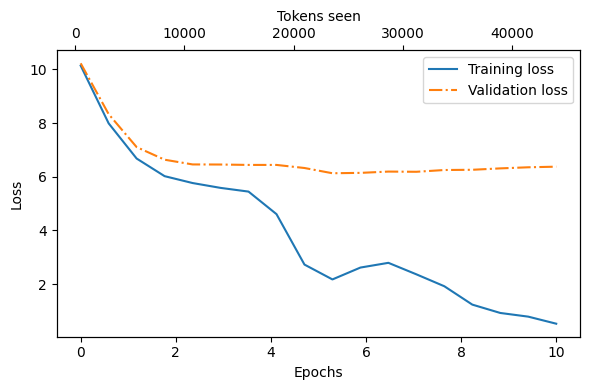

In [78]:
epochs_seen = torch.linspace(
    0,
    num_epochs,
    len(train_losses),
)

plot_losses(
    epochs_seen,
    tokens_seen,
    train_losses,
    val_losses,
)

### 7. Saving and loading the model

A model checkpoint stores the learned parameter tensors. The architecture configuration is still required to reconstruct the model before loading them.

In [80]:
checkpoint_dir = (
    Path.cwd().parent
    / "checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

model_path = (
    checkpoint_dir
    / "mini_gpt_model.pth"
)

torch.save(
    model.state_dict(),
    model_path,
)

print("Saved to:", model_path)
print(
    "Checkpoint size:",
    round(
        model_path.stat().st_size / 1024**2,
        1,
    ),
    "MB",
)

Saved to: /Users/sergiogomez/Repos/llm-lab/01_pretraining/mini_gpt/checkpoints/mini_gpt_model.pth
Checkpoint size: 633.9 MB
